In [ ]:
from vae_project.imports import *
from vae_project.dataset import *
from vae_project.utils import *
from vae_project.train.hooks import *
from vae_project.models.langevin import *
from vae_project import get_dataset
from vae_project.evaluate import evaluate_reconstructions
from torchvision.utils import save_image
import pandas as pd

In [ ]:
train_ds, val_ds = get_dataset("../data"), get_dataset('../data', train=False)

batch_tfms = [ToBatchTransform(tv.transforms.Pad(2)), Colorize('label')]
collate_fn = CollateWithTransforms(batch_tfms)

In [ ]:
bs = 128
val_dl = DataLoader(val_ds, bs*2, collate_fn=collate_fn)

In [ ]:
model = t.load("./vampprior_results/vp_vae_model.pt", map_location=default_device, weights_only=False)

In [ ]:
n = 2_000
eval_ds = subset(ColoredMNIST('../data', train=False, color_type='label', download=True), n=n)
langevin_params = dict(
    step_sz = 0.9,
    n_steps=0,
)
dl = DataLoader(subset(val_ds, n=n), batch_size=bs, collate_fn=CollateWithTransforms(batch_tfms))
recon_ds = ReconstructDataset(dl, model, langevin_kwargs=langevin_params)

  0%|          | 0/16 [00:00<?, ?it/s]

<Axes: >

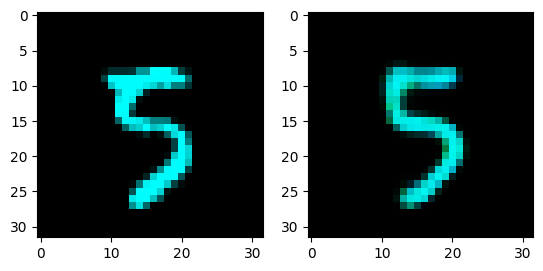

In [ ]:
i = -1
ax = plt.subplots(ncols=2)[1]
show_img(eval_ds[i], ax[0])
show_img(recon_ds[i], ax[1])

## Evaluation

In [ ]:
langevin_params['step_sz'] = 0.005
n_steps_values = [0, 5, 10, 20, 50, 100]
metrics_list = []

In [ ]:
# Load and evaluate different models
model_paths = [
    "./vae.pt",
    "./iwae.pt",
    "../samples/vampprior_results/vp_vae_model.pt"
 ]

In [ ]:
for model_path in model_paths:
    print(f"Generating GIFs and images for model: {model_path}")
    model = t.load(model_path, map_location=default_device, weights_only=False)
    for n_steps in n_steps_values:
        langevin_params['n_steps'] = n_steps
        recon_ds = ReconstructDataset(dl, model, langevin_kwargs=langevin_params)
        batch = next(iter(dl))[0][:49].to(default_device)
        _, _, _, history = langevin_dynamics(model, batch, n_steps=n_steps, step_sz=langevin_params['step_sz'], return_hist=True)
        gif_filename = f"{model_path.split('/')[-1].split('.')[0]}_nsteps_{n_steps}.gif"
        png_filename = f"{model_path.split('/')[-1].split('.')[0]}_nsteps_{n_steps}.png"
        
        # Save GIF
        animate_langevin(history, model, fn=f'step_sz0.005/{gif_filename}', fps=7, scale=2)
        
        # Save final batch as PNG
        final_batch = model.decode(history[:, -1].to(default_device)).clamp(0, 1)
        grid = make_grid(final_batch, nrow=7, padding=2, pad_value=1)
        save_image(grid, f'step_sz0.005/{png_filename}')
        print(f"Saved {gif_filename} and {png_filename}")

Generating GIFs and images for model: ./vae.pt


  0%|          | 0/16 [00:00<?, ?it/s]

Saved animation to step_sz0.005/vae_nsteps_0.gif
Saved vae_nsteps_0.gif and vae_nsteps_0.png


  0%|          | 0/16 [00:00<?, ?it/s]

Saved animation to step_sz0.005/vae_nsteps_5.gif
Saved vae_nsteps_5.gif and vae_nsteps_5.png


...

Saved animation to step_sz0.005/vp_vae_model_nsteps_20.gif
Saved vp_vae_model_nsteps_20.gif and vp_vae_model_nsteps_20.png


  0%|          | 0/16 [00:00<?, ?it/s]

Saved animation to step_sz0.005/vp_vae_model_nsteps_50.gif
Saved vp_vae_model_nsteps_50.gif and vp_vae_model_nsteps_50.png


  0%|          | 0/16 [00:00<?, ?it/s]

Saved animation to step_sz0.005/vp_vae_model_nsteps_100.gif
Saved vp_vae_model_nsteps_100.gif and vp_vae_model_nsteps_100.png


In [ ]:
all_data = []
for model_path in model_paths:
    print(f"Evaluating model: {model_path}")
    model = t.load(model_path, map_location=default_device, weights_only=False)
    metrics_list = []
    for n_steps in n_steps_values:
        langevin_params['n_steps'] = n_steps
        recon_ds = ReconstructDataset(dl, model, langevin_kwargs=langevin_params)
        metrics = evaluate_reconstructions(eval_ds, recon_ds)
        metrics['n_steps'] = n_steps
        metrics_list.append(metrics)
    
    metrics_df = pd.DataFrame(metrics_list)
    all_data.append(metrics_df)
    print(metrics_df)

Evaluating model: ./vae.pt


  0%|          | 0/16 [00:00<?, ?it/s]

Creating feature extractor "inception-v3-compat" with features ['2048', 'logits_unbiased']
Extracting features from input1
Processing samples                                                           
Extracting features from input2
Processing samples                                                           
Inception Score: 2.283691151360282 ± 0.03526155468852737
Frechet Inception Distance: 19.38398135276242
Kernel Inception Distance: 0.009068355560302735 ± 0.0005064959887436401          


  0%|          | 0/16 [00:00<?, ?it/s]

Creating feature extractor "inception-v3-compat" with features ['2048', 'logits_unbiased']
Extracting features from input1
Processing samples                                                           
Extracting features from input2
Processing samples                                                           
Inception Score: 2.283691151360282 ± 0.03526155468852737
Frechet Inception Distance: 19.206277124146368
Kernel Inception Distance: 0.009035351276397706 ± 0.0004827701531295632          


...

Creating feature extractor "inception-v3-compat" with features ['2048', 'logits_unbiased']
Extracting features from input1
Processing samples                                                           
Extracting features from input2
Processing samples                                                           
Inception Score: 2.283691151360282 ± 0.03526155468852737
Frechet Inception Distance: 18.551003306963935
Kernel Inception Distance: 0.008724658489227296 ± 0.00046979439446360305        


  0%|          | 0/16 [00:00<?, ?it/s]

Creating feature extractor "inception-v3-compat" with features ['2048', 'logits_unbiased']
Extracting features from input1
Processing samples                                                           
Extracting features from input2
Processing samples                                                           
Inception Score: 2.283691151360282 ± 0.03526155468852737
Frechet Inception Distance: 18.827118275060116
                                                                                 

   inception_score_mean  inception_score_std  frechet_inception_distance  \
0              2.283691             0.035262                   17.981233   
1              2.283691             0.035262                   18.228176   
2              2.283691             0.035262                   18.274797   
3              2.283691             0.035262                   18.038661   
4              2.283691             0.035262                   18.551003   
5              2.283691             0.035262                   18.827118   

   kernel_inception_distance_mean  kernel_inception_distance_std  n_steps  
0                        0.008140                       0.000442        0  
1                        0.008218                       0.000446        5  
2                        0.008284                       0.000459       10  
3                        0.008104                       0.000435       20  
4                        0.008725                       0.000470       50  
5          

Kernel Inception Distance: 0.008967700004577637 ± 0.0005061739978019878
